Implementar una aproximación del algoritmo descrito en el PDF proporcionado, utilizando para ello las parejas de imágenes de ejemplo suministradas.

2008


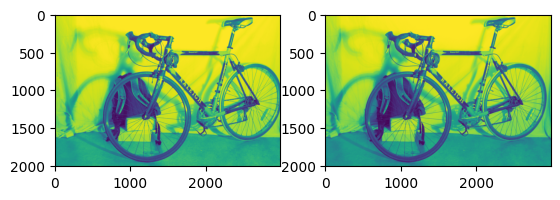

In [3]:
import cv2
from matplotlib import pyplot as plt

img1 = cv2.imread('images/im0.png',0) #queryimage # left image
img2 = cv2.imread('images/im1.png',0) #trainimage # right image
print(img1.shape[0])
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)
plt.show()


(2008, 2988)


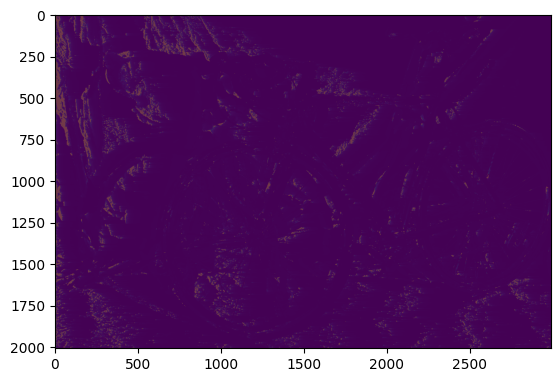

In [10]:
import numpy as np
import math
import matplotlib.pyplot as plt

def new_image_like(img1):
    """Crea un lienzo nuevo para guardar los valores de profundidad."""
    return np.zeros_like(img1, dtype=np.float32)

def pixels_from_img1(img1):
    pass

def get_feature_descriptor(img, i, j):
    """Extrae una ventana de la imagen."""
    x1 = max(0, i - 2)
    x2 = min(img.shape[1], i + 3)

    y1 = max(0, j - 2)
    y2 = min(img.shape[0], j + 3)

    mask = img[y1:y2, x1:x2]
    return mask

def columns(img):
    return img.shape[-1]

def score_feature_match(f_ij, f_i2j):
    """Calcula la diferencia entre dos ventanas."""
    # Pequeña seguridad por si los bordes generan ventanas de distinto tamaño
    if f_ij.shape != f_i2j.shape:
        return np.inf
    return math.dist(f_ij.ravel(), f_i2j.ravel())

# Se añade ndisp a los argumentos
def compute_depth(img1, img2, diff_x, f, p, ndisp, step=1):
    depth = new_image_like(img1)
    print(depth.shape)
    pixels = pixels_from_img1(img1)
    
    # CORRECCIÓN 1: NumPy devuelve (height, width), no al revés.
    height, width = img1.shape 
    width2 = img2.shape[1] # width es la segunda dimensión
    
    for i in range(3, width-2, step):
        for j in range(3, height-2, step):
            f_ij = get_feature_descriptor(img1, i, j)
            best_score = np.inf
            best_i = np.nan
            
            # ndisp ahora viene de los argumentos
            start_search = max(3, i - ndisp)
            
            for i2 in range(start_search, i):
                f_i2j = get_feature_descriptor(img2, i2, j)
                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            
            # CORRECCIÓN 2: En numpy es [fila, col] -> [j, i]
            # Si best_i es NaN (no encontró nada), no calculamos
            if not np.isnan(best_i):
                denom = (i - best_i)
                if abs(denom) > EPSILON:
                     depth[j, i] = f * p * diff_x / denom
    return depth

f = 5299.313
# width y height ya se calculan bien dentro de la función
doffs = 174.186
baseline = 177.288 # in mm
ndisp = 180
p = 1 
EPSILON = 0.000001
step = 2 

# Verificamos que las imágenes estén cargadas antes de llamar
if 'img1' in locals() and 'img2' in locals():
    # Se pasa ndisp en la llamada
    depth_img = compute_depth(img1, img2, baseline, f, p, ndisp, step)
    plt.imshow(depth_img)
    plt.show()
else:
    print("Por favor carga 'img1' e 'img2' antes de ejecutar.")

In [6]:
# Copia de Seguridad

import numpy as np
import math

def new_image_like(img1):
    """Crea un lienzo nuevo para guardar los valores de profundidad."""
    return np.zeros_like(img1, dtype=np.float32)

def pixels_from_img1(img1):
    pass

def get_feature_descriptor(img, i, j):
    """Extrae una ventana de la imagen."""
    x1 = max(0, i - 2)
    x2 = min(img.shape[1], i + 3)

    y1 = max(0, j - 2)
    y2 = min(img.shape[0], j + 3)

    mask = img[y1:y2, x1:x2]
    return mask

def columns(img):
    return img.shape[-1]

def score_feature_match(f_ij, f_i2j):
    """Calcula la diferencia entre dos ventanas."""
    return math.dist(f_ij.ravel(), f_i2j.ravel())

def compute_depth(img1, img2, diff_x, f, p):
    depth = new_image_like(img1)
    print(depth.shape)
    pixels = pixels_from_img1(img1)
    width, height = img1.shape
    width2, _ = img2.shape
    for i in range(3, width-2):
        for j in range(3, height-2):
            f_ij = get_feature_descriptor(img1, i, j)
            best_score = np.inf
            best_i = np.nan
            for i2 in range(3, width2-2):
                f_i2j = get_feature_descriptor(img2, i2, j)
                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            depth[i, j] = f * p * diff_x / (i - best_i + EPSILON)
    return depth

f= 5299.313
width=2988
height=2008
doffs=174.186
baseline=177.288 #in mm
ndisp=180
p = 1 # CAMBIAR
EPSILON = 0.000001
depth_img = compute_depth(img1, img2, baseline, f, p)
plt.imshow(depth_img)

(2008, 2988)


KeyboardInterrupt: 